In [2]:
#!pip install tensorflow==2.7.0

ERROR: Could not find a version that satisfies the requirement pyplot (from versions: none)
ERROR: No matching distribution found for pyplot


In [3]:
#!pip install pydot

In [6]:
import pandas as pd
import numpy as np
# IMPORTING VISUALIZATION LIBRARIES
import matplotlib.pyplot as plt
import pydot
import seaborn as sns
# IMPORTING EVALUATION LIBRARIES
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
# IMPORTING DEEP LEARNING LIBRARIES
import tensorflow
import keras
from keras.datasets import mnist
from keras.utils.np_utils import to_categorical
from keras.models import Sequential
from tensorflow.keras import layers
from keras.layers.core import Dense,Activation,Dropout
from keras.wrappers.scikit_learn import KerasClassifier

In [7]:
# LOADING THE DATASET
fashion_train=pd.read_csv('fashion-mnist_train.csv')
fashion_test=pd.read_csv('fashion-mnist_test.csv')
fashion_train.shape,fashion_test.shape

((60000, 785), (10000, 785))

In [9]:
x_train_fashion=fashion_train.drop('label',axis=1)
y_train_fashion=fashion_train['label']
x_test_fashion=fashion_test.drop('label',axis=1)
y_test_fashion=fashion_test['label']

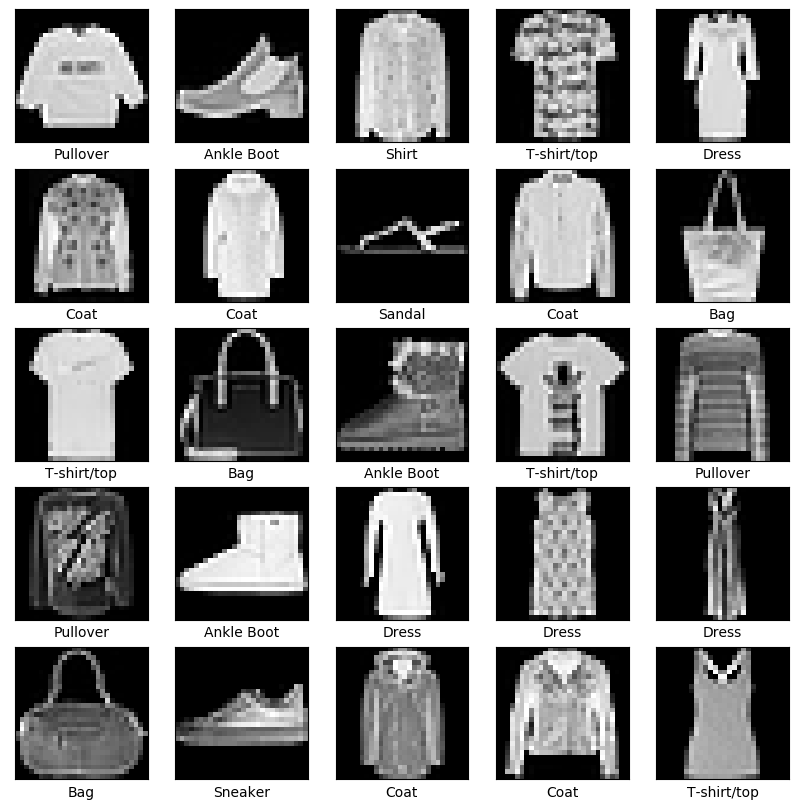

In [12]:
# VISUALIZING THE DATASET
x_train_reshape=x_train_fashion.values.reshape(-1,28,28)
x_test_reshape=x_test_fashion.values.reshape(-1,28,28)
col_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle Boot']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train_reshape[i],cmap='gray')
    plt.xlabel(col_names[y_train_fashion[i]])

In [14]:
y_train_fashion.value_counts()

9    6000
8    6000
7    6000
6    6000
5    6000
4    6000
3    6000
2    6000
1    6000
0    6000
Name: label, dtype: int64

In [15]:
# PREPROCESSING THE OUTPUT
y_train_fashion=to_categorical(y_train_fashion,num_classes=10)
y_test_fashion=to_categorical(y_test_fashion,num_classes=10)

In [21]:
y_train_fashion[2]

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.], dtype=float32)

In [25]:
# CREATING BASE NEURAL NETWORK
model=keras.Sequential([
    layers.Dense(128,activation='relu',input_shape=(784,)),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(10,activation='softmax')
])

In [26]:
# COMPILING THE MODEL
model.compile(loss="categorical_crossentropy",optimizer="adam",metrics=['accuracy'])

In [27]:
# MODEL FITTING
history=model.fit(x_train_fashion,y_train_fashion,batch_size=100,epochs=30,validation_data=(x_test_fashion,y_test_fashion))

Epoch 1/30
600/600 [==============================] - 3s 3ms/step - loss: 0.7997 - accuracy: 0.7200 - val_loss: 0.4715 - val_accuracy: 0.8323
Epoch 2/30
600/600 [==============================] - 2s 3ms/step - loss: 0.5594 - accuracy: 0.8071 - val_loss: 0.4193 - val_accuracy: 0.8491
Epoch 3/30
600/600 [==============================] - 2s 3ms/step - loss: 0.5174 - accuracy: 0.8205 - val_loss: 0.4039 - val_accuracy: 0.8558
Epoch 4/30
600/600 [==============================] - 2s 3ms/step - loss: 0.4833 - accuracy: 0.8318 - val_loss: 0.4168 - val_accuracy: 0.8639
Epoch 5/30
600/600 [==============================] - 2s 3ms/step - loss: 0.4678 - accuracy: 0.8376 - val_loss: 0.4211 - val_accuracy: 0.8634
Epoch 6/30
600/600 [==============================] - 2s 3ms/step - loss: 0.4502 - accuracy: 0.8444 - val_loss: 0.4047 - val_accuracy: 0.8703
Epoch 7/30
600/600 [==============================] - 2s 3ms/step - loss: 0.4387 - accuracy: 0.8469 - val_loss: 0.4255 - val_accuracy: 0.8644
Epoch 

In [31]:
test_loss,test_acc=model.evaluate(x_test_fashion,y_test_fashion)
print("Fashion MNIST Test Accuracy:",round(test_acc,4))

313/313 [==============================] - 0s 1ms/step - loss: 0.3307 - accuracy: 0.8845
Fashion MNIST Test Accuracy: 0.8845


In [32]:
# PREDICT THE LABELS
y_pred=model.predict(x_test_fashion)
y_predict=np.argmax(y_pred,axis=1)
y_test_fashion_eval=np.argmax(y_test_fashion,axis=1)

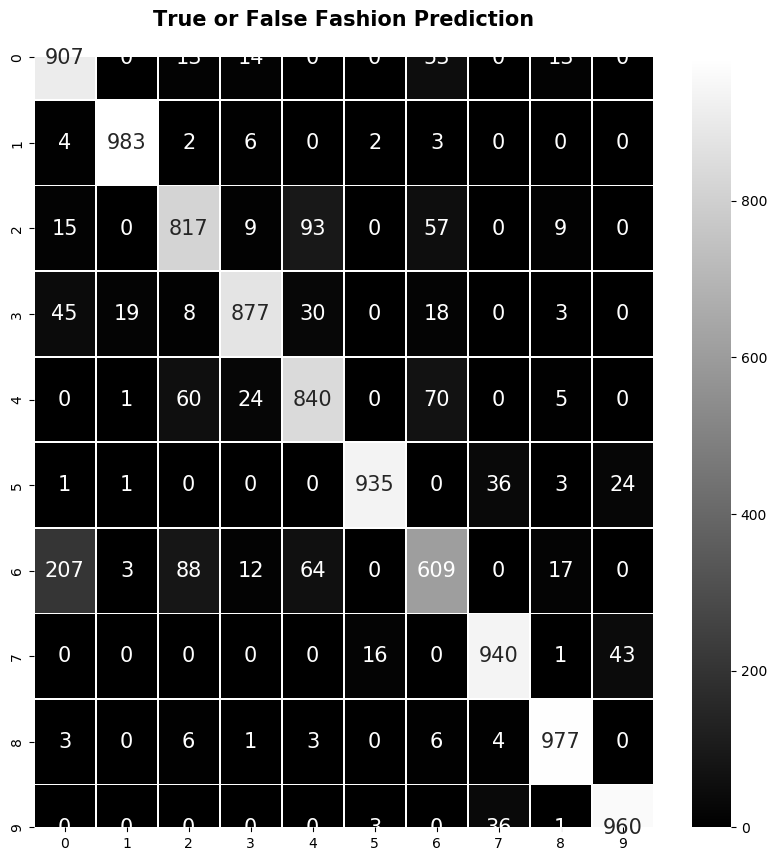

In [34]:
# EVALUATION AND VISUALIZATION
con_mat=confusion_matrix(y_test_fashion_eval,y_predict)
plt.style.use('seaborn-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidths=0.5,fmt="d",cmap="gray")
plt.title("True or False Fashion Prediction\n",fontweight='bold',fontsize=15)
plt.show()

In [35]:
print(classification_report(y_test_fashion_eval,y_predict))
print(history.history.keys())

              precision    recall  f1-score   support

           0       0.77      0.91      0.83      1000
           1       0.98      0.98      0.98      1000
           2       0.82      0.82      0.82      1000
           3       0.93      0.88      0.90      1000
           4       0.82      0.84      0.83      1000
           5       0.98      0.94      0.96      1000
           6       0.75      0.61      0.67      1000
           7       0.93      0.94      0.93      1000
           8       0.95      0.98      0.96      1000
           9       0.93      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


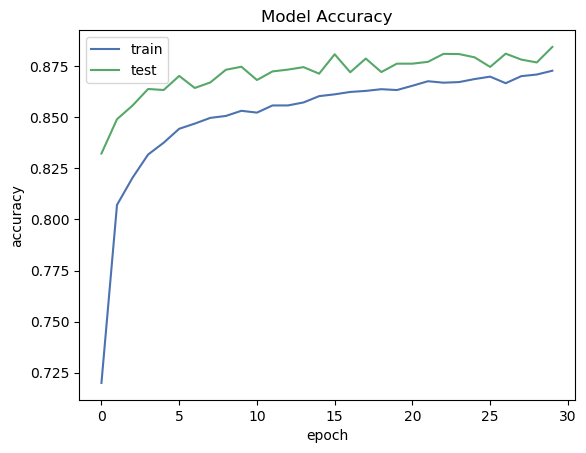

In [42]:
# ACCURACY VISUALIZATION
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'],loc='best')
plt.show()

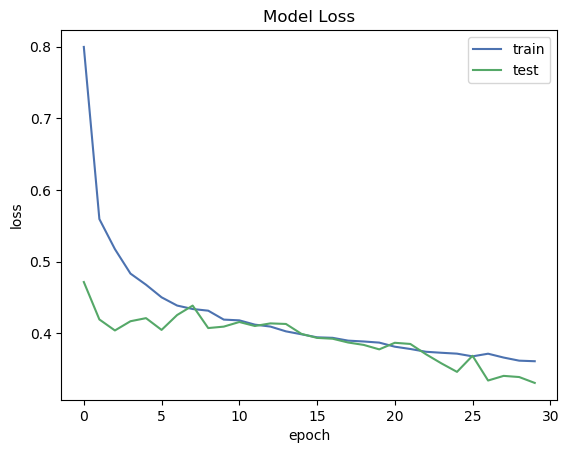

In [44]:
# LOSS VISUALIZATION
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','test'],loc='best')
plt.show()

In [45]:
# TENSOR FLOW: tf.expand_dims(x_test_fashion[0])
Y_predict=model.predict(x_test_fashion.loc[[0],:].values)
Y_predict=np.argmax(Y_predict,axis=1)
y_test_fashion_eval=np.argmax(y_test_fashion,axis=1)

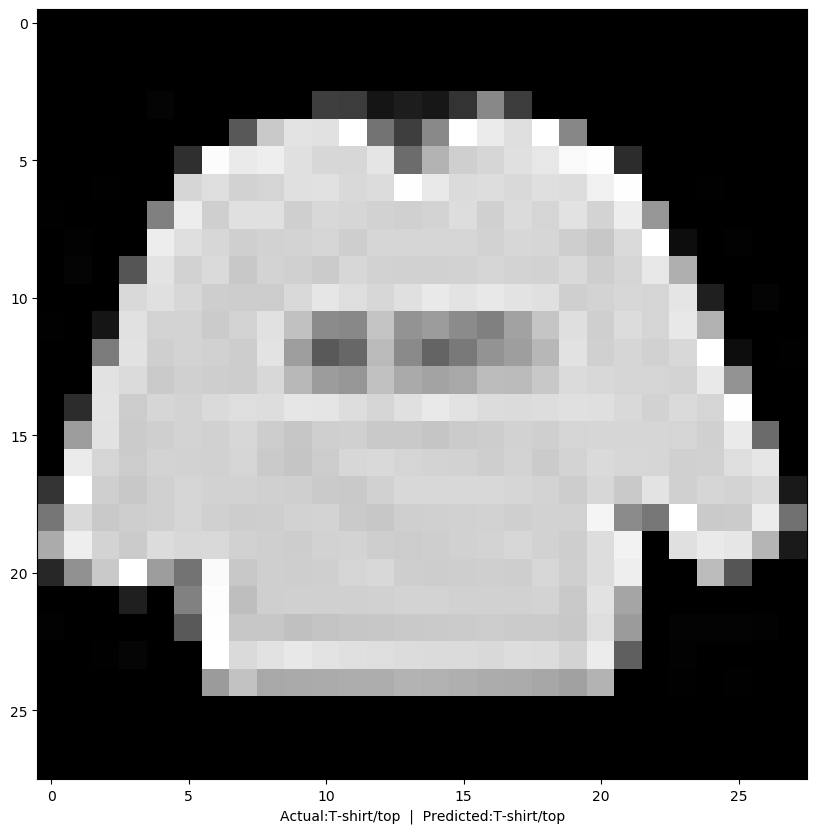

In [62]:
plt.figure(figsize=(10,10))
plt.imshow(x_train_reshape[0],cmap="gray")
plt.xlabel("Actual:{}  |  Predicted:{}".format(col_names[y_test_fashion_eval[0]],col_names[Y_predict[0]]))
plt.show()